In [19]:
import os 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import gabor

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [2]:
img_path = "./eye_disease_dataset/cataract/_0_4015166.jpg"

original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

original_img.shape, original_img.dtype

((256, 256, 3), dtype('uint8'))

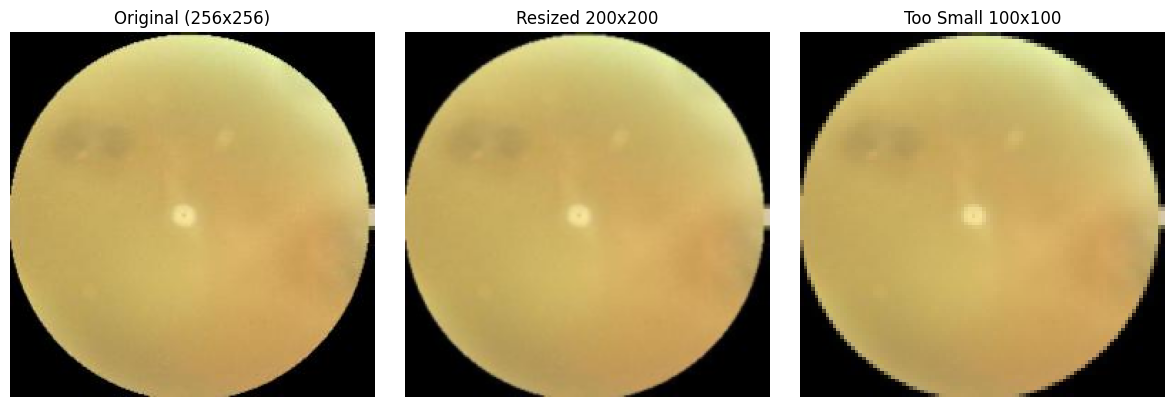

In [3]:
resized_img = cv2.resize(original_img, (200, 200), interpolation=cv2.INTER_AREA)
too_small_img = cv2.resize(original_img, (100, 100), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img, cmap="gray")
plt.title(f"Original ({original_img.shape[1]}x{original_img.shape[0]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(resized_img, cmap="gray")
plt.title(f"Resized 200x200")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(too_small_img, cmap="gray")
plt.title("Too Small 100x100")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
def load_data(dataset_path, dir_list, image_size):
    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        dir_path = os.path.join(dataset_path, directory)
        for filename in os.listdir(dir_path):
            # get every img file in the dir path
            path = os.path.join(dir_path, filename)
            # since this is an xray images
            # its better to load the image in grayscale
            # having it only on 1 channel makes computation efficient
            image = cv2.imread(path)
            image =  cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # resize image
            image = cv2.resize(
                image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC
            )
            # # normalize values (1/255 because 8 bit pixel images)
            # image = image / 255.0
            # append
            X.append(image)
            # mark true for tuberculosis and false for normal
            if directory == "normal":
                y.append([0])
            elif directory == "cataract":
                y.append([1])
            elif directory == "diabetic_retinopathy":
                y.append([2])
            elif directory == "glaucoma":
                y.append([3])
            else:
                raise ValueError("no class for:", directory)

    X = np.array(X)
    y = np.array(y)

    # Shuffle the data
    X, y = shuffle(X, y)

    print(f"Number of image sample: {len(X)}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    return X, y

In [42]:
IMG_WIDTH, IMG_HEIGHT = (260, 260)

X, y = load_data("./eye_disease_dataset", ["cataract", "diabetic_retinopathy", "glaucoma", "normal"], (IMG_WIDTH, IMG_HEIGHT))

Number of image sample: 4217
X shape: (4217, 260, 260, 3)
y shape: (4217, 1)


In [95]:
def class_percentage(y):
    y = np.array(y).flatten()

    class_names = {0: "normal", 1: "cataract", 2: "diabetic_retinopathy", 3: "glaucoma"}

    sample_size = len(y)
    print(f"Total samples: {sample_size}\n")

    unique, counts = np.unique(y, return_counts=True)

    for cls, count in zip(unique, counts):
        percentage = (count * 100.0) / sample_size
        name = class_names.get(cls, f"Class {cls}")
        print(f"{name}: {percentage:.2f}%  ({count} samples)")

In [12]:
class_percentage(y)

Total samples: 4217

normal: 25.47%  (1074 samples)
cataract: 24.61%  (1038 samples)
diabetic_retinopathy: 26.04%  (1098 samples)
glaucoma: 23.88%  (1007 samples)


In [26]:
def plot_sample_images(X, y, n=20):
    y = y.flatten()

    class_names = {0: "normal", 1: "cataract", 2: "diabetic_retinopathy", 3: "glaucoma"}

    for label in class_names.keys():
        idx = np.where(y == label)[0]

        images = X[idx][:n]

        columns_n = 10
        rows_n = int(np.ceil(len(images) / columns_n))

        plt.figure(figsize=(20, 2 * rows_n))

        for i, image in enumerate(images, 1):
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image.squeeze(), cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Eye: {class_names[label]}")
        plt.show()

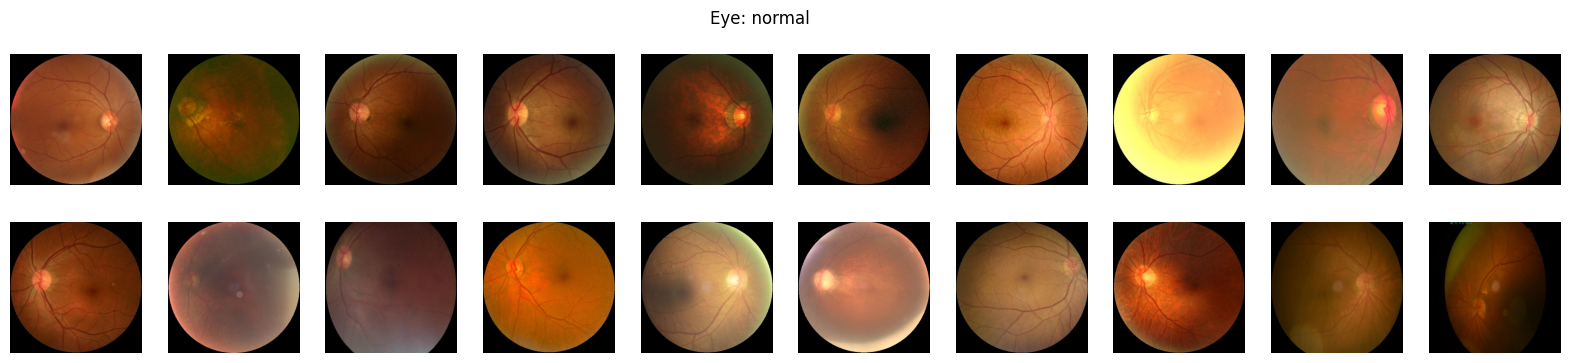

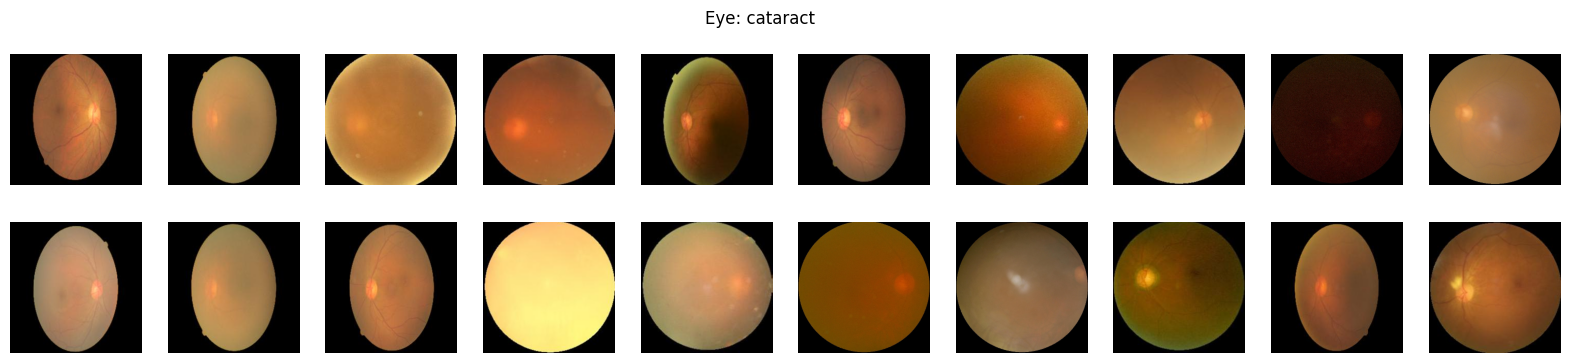

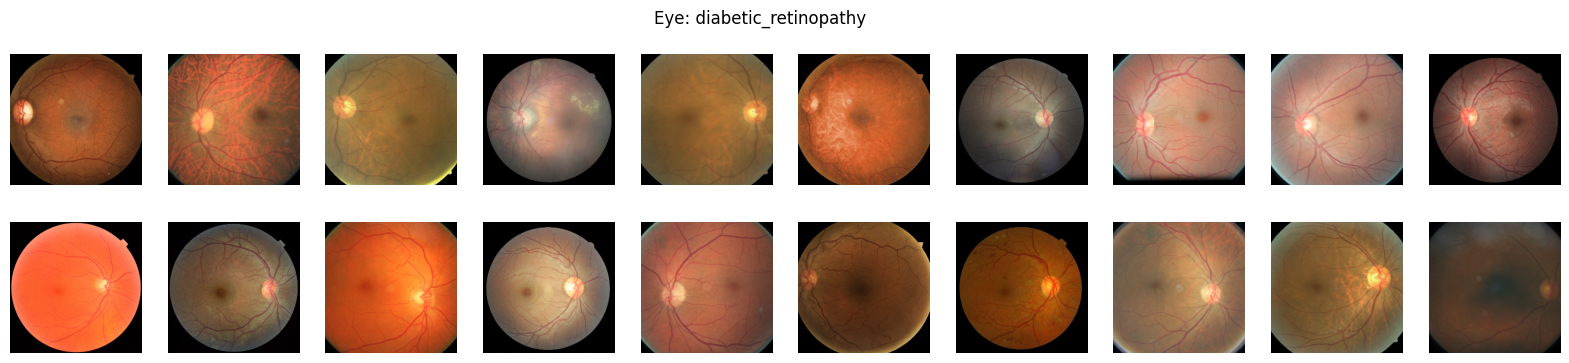

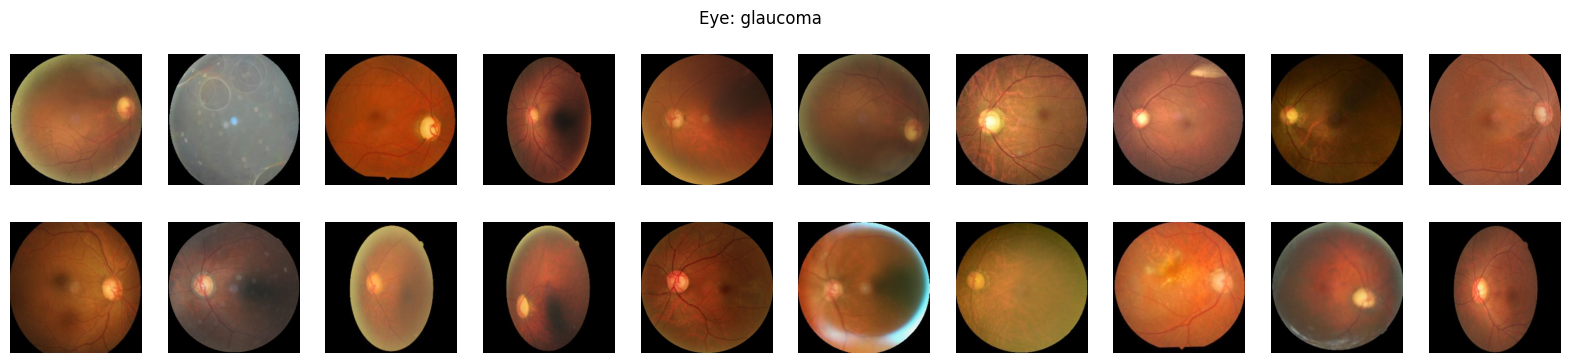

In [27]:
plot_sample_images(X, y)

In [87]:
def apply_clahe(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    per channel on an RGB image.
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    channels = cv2.split(image_rgb)
    enhanced = [clahe.apply(ch) for ch in channels]
    return cv2.merge(enhanced)


def preprocess_dataset(X_raw):
    return np.array([apply_clahe(img) for img in X_raw], dtype=np.uint8)

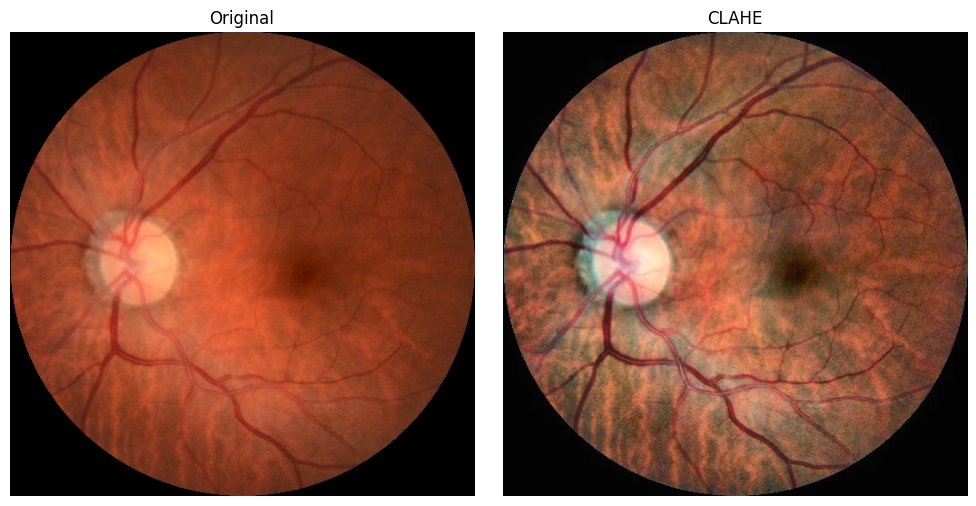

In [88]:
image_path = "./eye_disease_dataset/normal/8_left.jpg"

img_rgb   = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
img_clahe = apply_clahe(img_rgb)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb);   axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(img_clahe); axes[1].set_title("CLAHE");    axes[1].axis("off")
plt.tight_layout()
plt.show()

In [89]:
def extract_intensity_stats(image_rgb):
    """
    Compute per-channel intensity statistics for R, G, B channels.
    """
    features = []

    for ch in range(3):
        pixels = image_rgb[:, :, ch].astype(np.float64).ravel()

        features.extend([
            np.mean(pixels), # mean intensity
            np.std(pixels), # standard deviation
            np.var(pixels), # variance
            skew(pixels), # skewness
            kurtosis(pixels), # kurtosis
            np.percentile(pixels, 25), # 25th percentile
            np.percentile(pixels, 50), # 50th percentile (median)
            np.percentile(pixels, 75), # 75th percentile
            np.percentile(pixels, 90), # 90th percentile
        ])

    return np.array(features, dtype=np.float32)


def get_intensity_stats_names():
    names = []

    for ch in ['R', 'G', 'B']:
        for stat in ['mean', 'std', 'var', 'skew', 'kurt', 'p25', 'p50', 'p75', 'p90']:
            names.append(f"intensity_{ch}_{stat}")

    return names

In [90]:
def extract_glcm_features(image_rgb, distances=(1, 3), angles=(0, 45, 90, 135)):
    """
    Compute GLCM texture features per RGB channel.
 
    Properties extracted (6):
        contrast, dissimilarity, homogeneity, energy, correlation, ASM
 
    Computed over:
        3 channels (R, G, B)
        x 6 properties
        x 2 distances
        x 4 angles
        = 144 features total
    """
    angles_rad = [np.deg2rad(a) for a in angles]
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
 
    features = []
    for ch in range(3):
        glcm = graycomatrix(
            image_rgb[:, :, ch],
            distances=list(distances),
            angles=angles_rad,
            levels=256,
            symmetric=True,
            normed=True
        )

        for prop in props:
            features.extend(graycoprops(glcm, prop).flatten())
 
    return np.array(features, dtype=np.float32)


def get_glcm_feature_names(distances=(1, 3), angles=(0, 45, 90, 135)):
    names = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']

    for ch in ['R', 'G', 'B']:
        for prop in props:
            for d in distances:
                for a in angles:
                    names.append(f"glcm_{ch}_{prop}_d{d}_a{a}")

    return names

In [92]:
def extract_features(X_preprocessed):
    features = []

    N = len(X_preprocessed)

    for i, img in enumerate(X_preprocessed):
        # extract features
        intensity = extract_intensity_stats(img)
        glcm = extract_glcm_features(img)

        # append features
        img_feat = np.concatenate([intensity, glcm])
        features.append(img_feat)

        # logging
        if (i + 1) % 50 == 0 or (i + 1) == N:
            print(f"{i+1}/{N}")

    return np.array(features, dtype=np.float32)

In [93]:
X_prep = preprocess_dataset(X_raw=X)
 
X_feat = extract_features(X_prep)

50/4217
100/4217
150/4217
200/4217
250/4217
300/4217
350/4217
400/4217
450/4217
500/4217
550/4217
600/4217
650/4217
700/4217
750/4217
800/4217
850/4217
900/4217
950/4217
1000/4217
1050/4217
1100/4217
1150/4217
1200/4217
1250/4217
1300/4217
1350/4217
1400/4217
1450/4217
1500/4217
1550/4217
1600/4217
1650/4217
1700/4217
1750/4217
1800/4217
1850/4217
1900/4217
1950/4217
2000/4217
2050/4217
2100/4217
2150/4217
2200/4217
2250/4217
2300/4217
2350/4217
2400/4217
2450/4217
2500/4217
2550/4217
2600/4217
2650/4217
2700/4217
2750/4217
2800/4217
2850/4217
2900/4217
2950/4217
3000/4217
3050/4217
3100/4217
3150/4217
3200/4217
3250/4217
3300/4217
3350/4217
3400/4217
3450/4217
3500/4217
3550/4217
3600/4217
3650/4217
3700/4217
3750/4217
3800/4217
3850/4217
3900/4217
3950/4217
4000/4217
4050/4217
4100/4217
4150/4217
4200/4217
4217/4217


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)

In [96]:
class_percentage(y_train)
class_percentage(y_test)

Total samples: 3373

normal: 25.47%  (859 samples)
cataract: 24.61%  (830 samples)
diabetic_retinopathy: 26.03%  (878 samples)
glaucoma: 23.90%  (806 samples)
Total samples: 844

normal: 25.47%  (215 samples)
cataract: 24.64%  (208 samples)
diabetic_retinopathy: 26.07%  (220 samples)
glaucoma: 23.82%  (201 samples)


In [97]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [98]:
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['saga']
}

logreg_grid = GridSearchCV(
    logreg_pipe,
    logreg_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [99]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(probability=True, random_state=42))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf']
}

svm_grid = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [100]:
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf__n_estimators': [500, 600, 700],       # push higher since 500 was best
    'rf__max_depth': [None, 3, 5],             # explore near None
    'rf__min_samples_split': [2, 3],             # 2 was best, stay close
    'rf__min_samples_leaf': [1, 2],              # 1 was best, stay close
    'rf__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [101]:
logreg_grid.fit(X_train, y_train.ravel())
svm_grid.fit(X_train, y_train.ravel())
rf_grid.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [None, 3, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2], 'rf__min_samples_split': [2, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- 

In [102]:
best_logreg = logreg_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [103]:
logreg_grid.best_params_, svm_grid.best_params_, rf_grid.best_params_

({'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'saga'},
 {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'},
 {'rf__max_depth': None,
  'rf__max_features': 'log2',
  'rf__min_samples_leaf': 1,
  'rf__min_samples_split': 2,
  'rf__n_estimators': 600})

In [104]:
logreg_acc = best_logreg.score(X_test, y_test)
svm_acc = best_svm.score(X_test, y_test)
rf_acc = best_rf.score(X_test, y_test)

In [105]:
print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")
print(f"SVM Accuracy: {svm_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Logistic Regression Accuracy: 0.7216
SVM Accuracy: 0.8495
Random Forest Accuracy: 0.8673


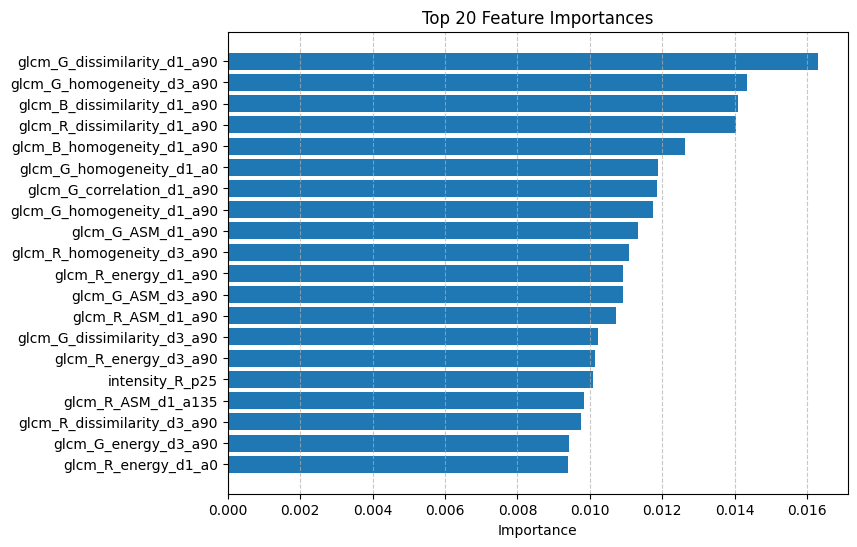

In [106]:
# get feature importances
importances = best_rf.named_steps['rf'].feature_importances_
feature_names = get_intensity_stats_names() + get_glcm_feature_names()

# sort importances descending
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = [feature_names[i] for i in indices]

TOP_K = 20

top_features = sorted_features[:TOP_K]
top_importances = sorted_importances[:TOP_K]

plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title(f"Top {TOP_K} Feature Importances")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [107]:
y_pred = best_rf.predict(X_test)

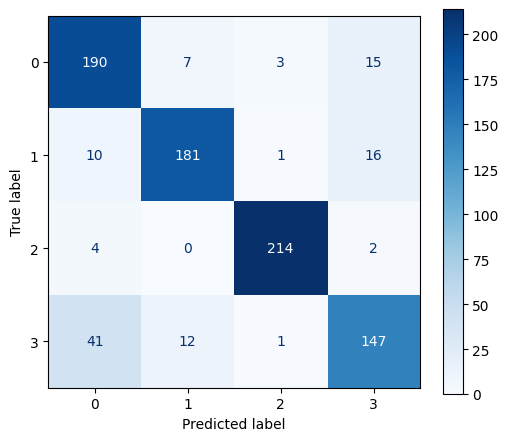

In [108]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.show()

In [109]:
report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report.head(4 + 4)

,precision,recall,f1-score,support
0,0.775510,0.883721,0.826087,215.000000
1,0.905000,0.870192,0.887255,208.000000
2,0.977169,0.972727,0.974943,220.000000
3,0.816667,0.731343,0.771654,201.000000
accuracy,0.867299,0.867299,0.867299,0.867299
macro avg,0.868586,0.864496,0.864985,844.000000
weighted avg,0.869789,0.867299,0.866999,844.000000


In [110]:
print("finished")

finished
